<a href="https://colab.research.google.com/github/Nicolas-ITIC/ML-PracticaTest_01/blob/main/Machine%20Learning/01_fonaments/FO_00_objectes_i_autocompletar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Les cinc preguntes: com esbrinar què tens a les mans

**Optativa d'Aprenentatge automàtic - DAM/DAW 2n**

A la sessió anterior vas llançar-te contra els exercicis i et vas quedar encallat. No
perquè no sàpigues programar: perquè tenies al davant una variable anomenada `digits` i no
tenies cap manera de saber què hi havia a dins. Vas provar `print(digits)`, et va sortir
una paret de números, i d'allà no es passa.

Avui no farem un manual d'objectes de Python. Farem **una anàlisi de dades de principi a
fi**, i les eines aniran sortint pel camí, cada una en el moment en què l'anàlisi es quedi
encallada sense ella. Perquè la idea central és aquesta:

> **No cal recordar els noms. Cal saber preguntar-los-hi.**

Ningú es recorda de memòria que un DataFrame té `.dtypes`, ni que un model entrenat té
`.coef_`. El que sí que sap tothom que treballa amb això és **com demanar-li a l'objecte
que t'ensenyi el que té**.

## El que t'enduràs d'avui

No una llista de mètodes: **un mètode**. Cinc preguntes que es fan a qualsevol conjunt de
dades, en aquest ordre, la primera vegada que se'l té al davant.

| | Pregunta | Amb què es respon |
|---|---|---|
| **1** | **Què és això?** | `type()` |
| **2** | **Què porta dins?** | `dir()` filtrat, `.keys()`, `.columns` |
| **3** | **Quina mida té i de quins tipus?** | `.shape`, `.dtypes`, `.info()` |
| **4** | **Hi falta res? Hi ha repetits?** | `.isna().sum()`, `.duplicated().sum()` |
| **5** | **Com es reparteix el que vull predir?** | `.value_counts()`, `.groupby()` |

Al final de la sessió sabràs fer-te aquestes cinc preguntes sol, davant d'unes dades que no
has vist mai. Les faràs servir tot el curs.

El quadern va en tres actes: primer les dades dels vins de dalt a baix, després unes dades
noves per comprovar que el mètode funciona sense ajuda, i al final un model entrenat, que
també és un objecte i també se li pot preguntar. La xuleta amb totes les taules és a l'últim
tram.

Tot el codi es pot executar. Executa'l, canvia'l, torna a executar-lo.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

print("numpy: ", np.__version__)
print("pandas:", pd.__version__)

numpy:  2.1.3
pandas: 2.2.3


---

# Acte 1 - Què hi ha aquí dins?

Comencem com comença de debò: algú et dona una línia de codi i unes dades. Res més.

In [67]:
from sklearn.datasets import load_wine

dades = load_wine()

Ja està. Tens **això** a les mans i no saps què és. Abans de poder analitzar res, has de
poder preguntar-li.

El primer impuls de tothom és imprimir-ho. Provem-ho, tallant la sortida, que si no ocupa
mitja pantalla:

In [6]:
print(str(dades)[:300])
print()
print("... i segueix. En total:", len(str(dades)), "caràcters.")

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+

... i segueix. En total: 4935 caràcters.


Aquesta és la paret de números. Hi ha coses que s'endevinen (`'data'`, `array`) però no s'hi
pot treballar. Imprimir no és preguntar.

## Pregunta 1 - Què és això?

**La primera pregunta és sempre la mateixa, i és aquesta.** Perquè tot el que podràs fer amb
una cosa depèn de què sigui aquella cosa: els mètodes d'una taula no són els d'un array, i
els d'un array no són els d'una llista.

In [7]:
print(type(dades))
print(type(dades).__name__)

<class 'sklearn.utils._bunch.Bunch'>
Bunch


`<class 'sklearn.utils._bunch.Bunch'>` es llegeix: això és de la classe `Bunch`. Amb
`.__name__` et quedes només el nom net, sense l'embolcall de `<class ...>`.

I ara tens una paraula, `Bunch`, que no et diu absolutament res. **Això no és un fracàs de la
pregunta: és el resultat normal.** El que has guanyat és que ja no tens "una cosa", tens un
`Bunch`, i als `Bunch` se'ls pot preguntar què porten.

La pregunta funciona amb qualsevol cosa, sempre igual:

In [8]:
print(type(3.14).__name__)
print(type("wine").__name__)
print(type([1, 2, 3]).__name__)
print(type({"a": 1}).__name__)

float
str
list
dict


## Pregunta 2 - Què porta dins?

Sé que és un `Bunch`. Necessito saber què hi ha a dins per poder-hi arribar. L'eina és
`dir()`, que et torna una llista amb **tots** els noms que hi ha dins de l'objecte: les dades
que porta i les coses que sap fer, barrejades i ordenades alfabèticament.

In [9]:
print(len(dir(dades)), "noms:")
print(dir(dades))

6 noms:
['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']


Sis noms, i ja hi ha informació de debò: `data`, `target`, `feature_names`, `target_names`,
`DESCR`, `frame`.

Amb un `Bunch` has tingut sort, i val la pena dir-ho perquè és una excepció: **scikit-learn
ha programat els `Bunch` perquè `dir()` torni just les claus que porten**, sense res més.
Amb la majoria d'objectes la llista és molt més llarga i molt més sorollosa, i ho veuràs en
un moment.

Un `Bunch` **també és un diccionari**, o sigui que té una segona manera, més curta, de mirar
què porta: `.keys()`. Les dues respostes a la pregunta 2 diuen el mateix.

In [10]:
print("dir(dades) :", dir(dades))
print("dades.keys():", list(dades.keys()))
print()
print("i s'hi arriba de les dues maneres:", dades.data is dades["data"])

dir(dades) : ['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']
dades.keys(): ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names']

i s'hi arriba de les dues maneres: True


De les sis claus, cinc s'entenen pel nom. La sisena, `frame`, no: mirem-la.

In [11]:
print("dades.frame ->", dades.frame)

dades.frame -> None


Buida. Existeix la clau però no hi ha res. **Apunta-t'ho**, que hi tornarem d'aquí a poc: és
la pista de com s'ha de carregar això de debò.

De moment, anem al que sí que té contingut: `dades.data`.

In [12]:
numeros = dades.data

print(str(numeros)[:200])

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]


Més números. **I aquí passa el que et volia ensenyar: la pregunta es repeteix amb el que hi
ha a dins.** No has acabat amb la pregunta 1 quan saps que la capsa és un `Bunch`. Cada cosa
que treus de la capsa és un objecte nou, i li tornes a preguntar el mateix.

In [68]:
print(type(numeros).__name__)

ndarray


Un `ndarray`: l'array de NumPy, la graella de números amb què treballa tot el càlcul de
Python. Segona pregunta, doncs: què porta dins un `ndarray`?

**Aquí `dir()` ensenya la seva cara de veritat**, la que tindrà amb gairebé tots els objectes
que et trobaràs:

In [14]:
tots = dir(numeros)

print("un ndarray té", len(tots), "noms a dins")
print()
print(tots[:24])

un ndarray té 170 noms a dins

['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__buffer__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__']


### El guió baix davant

Cent seixanta-nou noms, i la majoria comencen per `__`: `__add__`, `__len__`, `__class__`...
Això no es pot llegir.

**Un nom que comença per guió baix és cosa interna de Python, no és per a tu.** Són els
engranatges: `__add__` és el que s'executa de debò quan escrius `a + b`, i `__len__` és el
que s'executa quan escrius `len(a)`. Existeixen, funcionen, i no els cridaràs mai
directament.

Així que la manera útil de fer servir `dir()` és **filtrant-los**:

In [69]:
publics = [n for n in dir(numeros) if not n.startswith("_")]

print(len(publics), "noms útils, de 169:")
print(publics)

74 noms útils, de 169:
['T', 'all', 'any', 'argmax', 'argmin', 'argpartition', 'argsort', 'astype', 'base', 'byteswap', 'choose', 'clip', 'compress', 'conj', 'conjugate', 'copy', 'ctypes', 'cumprod', 'cumsum', 'data', 'device', 'diagonal', 'dot', 'dtype', 'dump', 'dumps', 'fill', 'flags', 'flat', 'flatten', 'getfield', 'imag', 'item', 'itemset', 'itemsize', 'mT', 'max', 'mean', 'min', 'nbytes', 'ndim', 'newbyteorder', 'nonzero', 'partition', 'prod', 'ptp', 'put', 'ravel', 'real', 'repeat', 'reshape', 'resize', 'round', 'searchsorted', 'setfield', 'setflags', 'shape', 'size', 'sort', 'squeeze', 'std', 'strides', 'sum', 'swapaxes', 'take', 'to_device', 'tobytes', 'tofile', 'tolist', 'tostring', 'trace', 'transpose', 'var', 'view']


De 169 a 73. Aquesta línia la faràs servir tot el curs, així que val la pena llegir-la a poc
a poc: recorre tots els noms de `dir(numeros)` i es queda **només** amb els que **no**
comencen per guió baix.

I ara ja es llegeix. Hi ha `shape`, `dtype`, `mean`, `std`, `min`, `max`, `reshape`,
`astype`... Encara no saps què fa cada un, però has passat de "no sé què tinc" a "tinc una
llista de 73 coses, i unes quantes tenen un nom que promet".

## Pregunta 3 - Quina mida té?

De la llista de 73, la que necessites ara es diu `shape`. Vols saber quantes files i quantes
columnes hi ha, perquè sense això no pots ni començar.

I el més natural del món és escriure-ho així:

In [70]:
try:
    numeros.shape()
except TypeError as e:
    print(type(e).__name__, "->", e)

TypeError -> 'tuple' object is not callable


### Atribut o mètode: la diferència que et farà perdre una hora

Aquest error el veuràs avui, i val més que el vegis aquí, tranquil, que no d'aquí a mitja
hora enmig d'un exercici. Després d'un punt hi pot haver dues coses molt diferents:

- Un **atribut** és una **dada** que l'objecte porta guardada. Es llegeix i prou. **No porta
  parèntesis.**
- Un **mètode** és una **acció** que l'objecte sap fer. L'has de **cridar**, i cridar-lo vol
  dir posar-li **parèntesis**.

La regla curta: **si és una dada, no hi ha parèntesis; si és una feina, sí.**

`shape` és una dada: la forma ja està calculada i guardada. `numeros.shape` **ja és** la
tupla `(178, 13)`. Escriure `numeros.shape()` vol dir "crida la tupla `(178, 13)`", i una
tupla no es pot cridar.

> **`TypeError: 'tuple' object is not callable` vol dir sempre el mateix: has posat
> parèntesis a una cosa que no és una funció.** Treu-los.

Sense parèntesis, doncs:

In [17]:
print("shape:", numeros.shape)
print("dtype:", numeros.dtype)
print("ndim: ", numeros.ndim)
print("size: ", numeros.size, "=", numeros.shape[0], "x", numeros.shape[1])

shape: (178, 13)
dtype: float64
ndim:  2
size:  2314 = 178 x 13


**178 files i 13 columnes.** 178 vins, 13 mesures de cada un, tots números decimals
(`float64`). Ja tens la mida i el tipus: la pregunta 3, resposta.

### L'altre cas, el que no peta

L'error dels parèntesis de més fa soroll i es veu de seguida. El contrari, deixar-se els
parèntesis d'un mètode, és més traïdor: **no peta**. Et surt una cosa rara i no un error.

In [18]:
print(numeros.mean)

<built-in method mean of numpy.ndarray object at 0x7bfd663c3e70>


`<built-in method mean of numpy.ndarray object at ...>`. Això no és la mitjana: és **el
mètode en si**, sense executar. Python t'ensenya l'etiqueta de la feina en lloc de fer-la,
perquè no li has demanat que la faci. Amb objectes de pandas la sortida diu `bound method`,
que és el mateix.

> **Quan a la sortida veus `method` en lloc de dades, t'has deixat els parèntesis.** És
> literalment tot el diagnòstic que necessites.

In [19]:
print("numeros.mean   ->", numeros.mean)
print("numeros.mean() ->", numeros.mean())

numeros.mean   -> <built-in method mean of numpy.ndarray object at 0x7bfd663c3e70>
numeros.mean() -> 69.13366292091617


I si dubtes de si una cosa és atribut o mètode abans d'equivocar-te, pregunta-ho:

In [20]:
print("callable(numeros.shape) ->", callable(numeros.shape))   # False: és un atribut
print("callable(numeros.mean)  ->", callable(numeros.mean))    # True: és un mètode

callable(numeros.shape) -> False
callable(numeros.mean)  -> True


## Tenim números, i no en podem fer res

Aquí l'anàlisi s'encalla de debò. Tens una graella de 178 x 13 números i **no saps què és cada
columna**. La primera columna és el grau d'alcohol? És el pH? Sense els noms no hi ha res a
dir.

Tornem a la pregunta 2 i al que ens quedava per obrir del `Bunch`: `feature_names`, `target`
i `target_names`.

In [21]:
print("feature_names, els noms de les 13 columnes de data:")
for i, nom in enumerate(dades.feature_names):
    print(f"  columna {i:2}  {nom}")

feature_names, els noms de les 13 columnes de data:
  columna  0  alcohol
  columna  1  malic_acid
  columna  2  ash
  columna  3  alcalinity_of_ash
  columna  4  magnesium
  columna  5  total_phenols
  columna  6  flavanoids
  columna  7  nonflavanoid_phenols
  columna  8  proanthocyanins
  columna  9  color_intensity
  columna 10  hue
  columna 11  od280/od315_of_diluted_wines
  columna 12  proline


In [22]:
print("target:      ", type(dades.target).__name__, dades.target.shape, dades.target.dtype)
print("els 20 primers:", dades.target[:20])
print()
print("target_names:", dades.target_names)

target:       ndarray (178,) int64
els 20 primers: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

target_names: ['class_0' 'class_1' 'class_2']


Ara sí que es llegeix el conjunt:

- `data` són les **mesures**: 178 vins x 13 mesures químiques.
- `target` és **la resposta correcta** de cada vi: 178 números, un per fila.
- `target_names` diu que aquells números (0, 1, 2) són **tres varietats** de raïm.

O sigui que la pregunta que acompanya aquestes dades és: **es pot endevinar la varietat d'un
vi a partir de la seva química?**

La primera fila, sencera i amb els noms al costat:

In [23]:
for nom, valor in zip(dades.feature_names, numeros[0]):
    print(f"  {nom:32} {valor}")
print()
print("  varietat:", dades.target[0], "->", dades.target_names[dades.target[0]])

  alcohol                          14.23
  malic_acid                       1.71
  ash                              2.43
  alcalinity_of_ash                15.6
  magnesium                        127.0
  total_phenols                    2.8
  flavanoids                       3.06
  nonflavanoid_phenols             0.28
  proanthocyanins                  2.29
  color_intensity                  5.64
  hue                              1.04
  od280/od315_of_diluted_wines     3.92
  proline                          1065.0

  varietat: 0 -> class_0


Funciona, però mira la feina que ha calgut per veure **una** fila: un `zip` dels noms amb els
números, i una consulta a `target_names` per traduir el 0. Per treballar així tota la sessió,
no.

### El `frame` buit era la pista

Recorda la clau `frame`, que era `None`. Els carregadors de scikit-learn accepten un argument
`as_frame=True`, i llavors l'omplen: et donen **les dades i els noms cosits en una sola
taula**.

In [24]:
dades_df = load_wine(as_frame=True)

print("type de .data: ", type(dades_df.data).__name__)
print("type de .frame:", type(dades_df.frame).__name__)
print("shape de .frame:", dades_df.frame.shape)

type de .data:  DataFrame
type de .frame: DataFrame
shape de .frame: (178, 14)


`DataFrame`: un tipus nou, i el que faràs servir per **mirar** les dades tot el curs. (L'array
de NumPy el faràs servir per **entrenar** models; són dos formats de la mateixa cosa.)

`.frame` fa **178 x 14**: les 13 mesures més una columna amb el target. Li canvio el nom a
aquesta columna, perquè `target` no diu res, i treballo sobre una còpia meva per no tocar el
que hi ha dins del `Bunch`.

In [71]:
vins = dades_df.frame.copy()
vins["classe"] = vins["target"]
vins = vins.drop(columns=["target"])

print(vins.shape)
print(list(vins.columns))

(178, 14)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'classe']


## Pregunta 3, una altra vegada: i això, quina mida té i de quins tipus és?

Objecte nou, les mateixes preguntes. `.shape` ja el coneixes i funciona igual. La novetat és
que un `DataFrame` es pot **mirar**, i el primer que es fa sempre és `.head()`: les primeres
files.

In [26]:
print("shape:", vins.shape)
print()
print(vins.head(3).iloc[:, :5])

shape: (178, 14)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium
0    14.23        1.71  2.43               15.6      127.0
1    13.20        1.78  2.14               11.2      100.0
2    13.16        2.36  2.67               18.6      101.0


He fet servir `.iloc[:, :5]` per no imprimir les 14 columnes de cop: vol dir "totes les files,
les 5 primeres columnes".

Fixa't que `.head()` **porta parèntesis**: és una feina, no una dada guardada. Si te'ls
deixes, ja saps què passa:

In [27]:
print(str(vins.head)[:70], "...")

<bound method NDFrame.head of      alcohol  malic_acid   ash  alcalini ...


`<bound method NDFrame.head of ...`. El mateix cas d'abans, amb un objecte de pandas.

He tallat la sortida a 70 caràcters a posta. Si l'imprimeixes sencera, pandas enganxa **la
taula de 178 files darrere de l'etiqueta**, i això encara confon més, perquè sembla que hagi
funcionat. El senyal que has d'atrapar és el començament: **si la sortida comença per
`<bound method`, t'has deixat els parèntesis.**

Ara el tipus de cada columna. A l'array només hi havia un `dtype` per a tot; en un DataFrame
cada columna pot ser d'un tipus diferent, i per això el plural: `.dtypes`.

In [28]:
print(vins.dtypes)

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
classe                            int64
dtype: object


Tretze columnes `float64` i la `classe` en `int64`. Té sentit: les mesures són decimals i la
varietat és un número enter. **Si aquí sortís `object` en una columna que esperes numèrica,
voldria dir que hi ha text barrejat**, i ho hauries d'arreglar abans de continuar.

Hi ha una manera de tenir la mida, els tipus i una cosa més en una sola línia: `.info()`.

In [29]:
vins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

178 entrades, 14 columnes, els tipus, la memòria que ocupa, i la columna del mig: **`178
non-null`** a totes. Això és una resposta anticipada a la pregunta 4, i hi arribem de seguida.

Abans, la millor primera mirada a unes dades numèriques: `.describe()`, que per a cada columna
et dona quants valors hi ha, la mitjana, la desviació típica, el mínim, els tres quartils i el
màxim.

In [30]:
print(vins[["alcohol", "malic_acid", "proline"]].describe().round(2))

       alcohol  malic_acid  proline
count   178.00      178.00   178.00
mean     13.00        2.34   746.89
std       0.81        1.12   314.91
min      11.03        0.74   278.00
25%      12.36        1.60   500.50
50%      13.05        1.87   673.50
75%      13.68        3.08   985.00
max      14.83        5.80  1680.00


Fixa't en l'escala: `alcohol` va d'11.03 a 14.83 i `proline` va de 278 a 1680. Són números de
mides completament diferents, i això tindrà conseqüències quan entrenis models basats en
distàncies. Te'n tornaràs a trobar a l'Acte 3, d'una manera que no esperaries.

## Una columna no és una taula

Ara vull treballar amb una columna sola. L'agafo, i **abans de res li pregunto què és**, que
per ara ja hauria de ser un reflex.

In [31]:
columna = vins["alcohol"]

print("type de vins           :", type(vins).__name__)
print("type de vins['alcohol']:", type(columna).__name__)

type de vins           : DataFrame
type de vins['alcohol']: Series


Un tipus nou: **`Series`**. Això es passa per alt i després confon molt: **una columna d'un
DataFrame no és un DataFrame**. És una `Series`, una altra classe, amb els seus propis
mètodes.

In [32]:
print("shape:", columna.shape, "(una sola dimensió, no (178, 1))")
print("dtype:", columna.dtype)
print("name: ", columna.name)
print()
print(columna.head(3))

shape: (178,) (una sola dimensió, no (178, 1))
dtype: float64
name:  alcohol

0    14.23
1    13.20
2    13.16
Name: alcohol, dtype: float64


Un parany petit i molt habitual: `vins["alcohol"]`, amb un nom, és una `Series`; però
`vins[["alcohol"]]`, amb **doble claudàtor** (una llista d'una sola columna), és un DataFrame
d'una columna. Es veuen gairebé igual a la pantalla i no tenen els mateixos mètodes.

In [33]:
print("vins['alcohol']   ->", type(vins["alcohol"]).__name__, vins["alcohol"].shape)
print("vins[['alcohol']] ->", type(vins[["alcohol"]]).__name__, vins[["alcohol"]].shape)

vins['alcohol']   -> Series (178,)
vins[['alcohol']] -> DataFrame (178, 1)


Com que és un tipus nou, té mètodes que el DataFrame no necessita. Els de resum els
reconeixeràs, i n'hi ha un que val la pena mirar-se: `.idxmax()`.

In [34]:
print("mitjana:  ", round(columna.mean(), 4))
print("desviació:", round(columna.std(), 4))
print("mínim:    ", columna.min())
print("màxim:    ", columna.max())
print()
print("idxmax(): ", columna.idxmax(), "<- no és el valor, és ON és")

mitjana:   13.0006
desviació: 0.8118
mínim:     11.03
màxim:     14.83

idxmax():  8 <- no és el valor, és ON és


El vi més alcohòlic fa **14.83 graus** i és el de la fila **8**. I com que tens l'índex de la
fila, pots anar a buscar-la sencera amb `.loc`:

In [35]:
print(vins.loc[columna.idxmax(), :"magnesium"])

alcohol              14.83
malic_acid            1.64
ash                   2.17
alcalinity_of_ash    14.00
magnesium            97.00
Name: 8, dtype: float64


Dues notes sobre coses que acaben de sortir i que despistaran:

- `.loc` i `.iloc` són **atributs** (sense parèntesis) però es fan servir amb **claudàtors**:
  `vins.loc[8, "alcohol"]`. Són l'excepció de la regla dels parèntesis. `.loc` busca **per
  etiqueta** i `.iloc` **per posició**.
- A pandas, `.idxmax()` torna l'**etiqueta de l'índex**; a NumPy, `.argmax()` torna la
  **posició**. Aquí coincideixen, perquè l'índex va de 0 a 177, però no sempre passa.

I una tercera, de regal: les columnes també són accessibles amb un punt, `vins.alcohol`, com
si fossin atributs. Amb els claudàtors sempre funciona; amb el punt, no sempre: prova-ho amb
la columna que es diu `od280/od315_of_diluted_wines` i veuràs per què.

## Pregunta 4 - Hi falta res? Hi ha repetits?

Aquesta pregunta es fa **abans** de calcular res, i no és una formalitat. Un valor que falta
enmig d'una columna fa que la mitjana surti d'un subconjunt sense avisar; una fila repetida
compta dues vegades i desequilibra el que vingui després.

Dues línies. `.isna()` marca amb `True` cada casella buida, i `.sum()` les compta.

In [36]:
print("isna() torna un", type(vins.isna()).__name__, "de la mateixa mida:", vins.isna().shape)
print()
print("valors que falten en total:", vins.isna().sum().sum())
print("files repetides:           ", vins.duplicated().sum())

isna() torna un DataFrame de la mateixa mida: (178, 14)

valors que falten en total: 0
files repetides:            0


**Zero i zero.** I això és una informació, no un anticlímax: vol dir que pots passar
directament a analitzar, sense netejar res.

El que no vol dir és que això sigui normal. **Wine està net perquè és un dataset d'exemple,
preparat per ensenyar.** Als fitxers de veritat hi falten dades gairebé sempre, i al quadern
de pandas obriràs un fitxer real amb el **47 %** dels valors buits en una columna, i hauràs
de decidir què hi fas. Per això la pregunta 4 es fa sempre: perquè el dia que la resposta no
sigui zero, t'has d'assabentar **abans** de calcular la mitjana, no després.

Per saber-ho reconèixer, mira com es veu quan sí que en falten:

In [37]:
amb_forats = pd.DataFrame({
    "a": [1.0, 2.0, np.nan, 4.0],
    "b": [10.0, np.nan, 30.0, 40.0],
})
print(amb_forats)
print()
print("forats per columna:")
print(amb_forats.isna().sum())
print()
print("dropna() -> sobreviuen", amb_forats.dropna().shape[0], "files de 4")
print("fillna(0):")
print(amb_forats.fillna(0))
print()
print("i l'original NO ha canviat:", amb_forats.isna().sum().sum(), "forats encara")

     a     b
0  1.0  10.0
1  2.0   NaN
2  NaN  30.0
3  4.0  40.0

forats per columna:
a    1
b    1
dtype: int64

dropna() -> sobreviuen 2 files de 4
fillna(0):
     a     b
0  1.0  10.0
1  2.0   0.0
2  0.0  30.0
3  4.0  40.0

i l'original NO ha canviat: 2 forats encara


`.dropna()` treu les files amb buits i `.fillna(valor)` els omple. Cap dels dos toca el
DataFrame original: **et tornen un de nou**. Si vols conservar el resultat, l'has d'assignar.

## Pregunta 5 - Com es reparteix el que vull predir?

Ja saps què tens, quina mida fa i que està net. L'última pregunta és sobre **la columna que
vols endevinar**: quantes classes hi ha i quantes mostres de cada una.

És la pregunta que més gent es salta, i la que més disgustos estalvia. `vins["classe"]` és
una `Series`, i a una `Series` li pots demanar `.value_counts()`.

In [38]:
compte = vins["classe"].value_counts()

print(compte)
print()
print("en ordre de classe, amb .sort_index():")
compte = compte.sort_index()
print(compte)
print()
print("proporcions:")
print((compte / len(vins)).round(3))

classe
1    71
0    59
2    48
Name: count, dtype: int64

en ordre de classe, amb .sort_index():
classe
0    59
1    71
2    48
Name: count, dtype: int64

proporcions:
classe
0    0.331
1    0.399
2    0.270
Name: count, dtype: float64


**59, 71 i 48**: un 33.1 %, un 39.9 % i un 27 %. Tres classes, bastant equilibrades.

Fixa't que `.value_counts()` ordena de més freqüent a menys (surt primer la classe 1, amb 71),
no pel valor de la classe; per veure-ho en ordre, `.sort_index()`.

I per què importa tant, això? Perquè et dona **el número a batre**. Si el teu model digués
sempre "classe 1" sense mirar res, encertaria el **39.9 %**. Qualsevol model ha de fer-ho
millor que aquest 39.9 %, o no ha après res. Si una classe tingués el 95 % de les mostres, un
model que digués sempre aquella classe encertaria el 95 % i el resultat semblaria excel·lent
sent inútil.

### La mateixa pregunta, però per classe

Ara ve el pas que converteix les cinc preguntes en una anàlisi de debò: **en què es
diferencien les tres varietats?** La mitjana de cada mesura, calculada per separat dins de
cada classe.

L'eina és `.groupby()`, i abans de fer-la servir mira bé què et torna, que aquí s'hi ensopega
molt:

In [39]:
agrupat = vins.groupby("classe")

print("type:", type(agrupat).__name__)
print("imprimir-lo no ensenya dades:", agrupat)
print()
print("grups:", list(agrupat.groups.keys()))
print("mides:", agrupat.size().to_dict())

type: DataFrameGroupBy
imprimir-lo no ensenya dades: <pandas.core.groupby.generic.DataFrameGroupBy object at 0x7bfd6633da90>

grups: [0, 1, 2]
mides: {0: 59, 1: 71, 2: 48}


`vins.groupby("classe")` **no** és un DataFrame: és un objecte d'agrupació
(`DataFrameGroupBy`). És una promesa, no una taula, i si l'imprimeixes no veus dades. Es
converteix en taula quan li demanes **què vols calcular** de cada grup:

In [40]:
mitjanes = agrupat.mean()

print("type:", type(mitjanes).__name__, " shape:", mitjanes.shape)
print()
print(mitjanes[["alcohol", "flavanoids", "color_intensity", "proline"]].round(2))

type: DataFrame  shape: (3, 13)

        alcohol  flavanoids  color_intensity  proline
classe                                               
0         13.74        2.98             5.53  1115.71
1         12.28        2.08             3.09   519.51
2         13.15        0.78             7.40   629.90


Això ja diu coses. Llegeix-ho per files:

- La **classe 0** és la més alcohòlica (**13.74**) i la que té més `proline`, amb molta
  diferència: **1115.71** contra 519.51 i 629.90.
- La **classe 2** és la que té menys `flavanoids` (**0.78** contra 2.98 i 2.08) i més
  `color_intensity` (**7.40**).
- La **classe 1** queda al mig en gairebé tot, i és la més fluixa en alcohol (**12.28**).

### Quina columna separa millor?

"Les mitjanes són diferents" no n'hi ha prou. `magnesium` fa 106.34, 94.55 i 99.31: són
números diferents, però la columna sencera es mou tant que aquesta diferència es perd dins del
soroll.

El que vols és una mesura que compari **la distància entre les mitjanes** amb **la dispersió de
la columna**. La més senzilla: el rang de les mitjanes dividit per la desviació típica de la
columna. Com més gran, millor separa.

In [41]:
numeriques = vins.drop(columns=["classe"])

rang_mitjanes = mitjanes.max() - mitjanes.min()      # Series: un valor per columna
dispersio = numeriques.std()                         # Series: un valor per columna
separacio = (rang_mitjanes / dispersio).sort_values(ascending=False)

print("type de separacio:", type(separacio).__name__)
print()
print(separacio.round(2))

type de separacio: Series

flavanoids                      2.20
od280/od315_of_diluted_wines    2.08
proline                         1.89
color_intensity                 1.86
total_phenols                   1.86
alcohol                         1.81
hue                             1.66
alcalinity_of_ash               1.31
proanthocyanins                 1.30
nonflavanoid_phenols            1.27
malic_acid                      1.25
magnesium                       0.83
ash                             0.77
dtype: float64


El rànquing: **`flavanoids` (2.20)**, `od280/od315_of_diluted_wines` (2.08), `proline` (1.89),
`color_intensity` (1.86). I a la cua, `ash` (0.77) i `magnesium` (0.83), que no separen
gairebé res.

Recorda aquests dos extrems, `flavanoids` i `ash`: a l'Acte 3 veuràs si un model entrenat
arriba a la mateixa conclusió pel seu compte.

### Veure-ho

L'última cosa. Dibuixem les dues millors columnes, una contra l'altra, amb un color per
classe, i al costat la pitjor. Si les tres varietats surten en tres zones separades, un model
les distingirà.

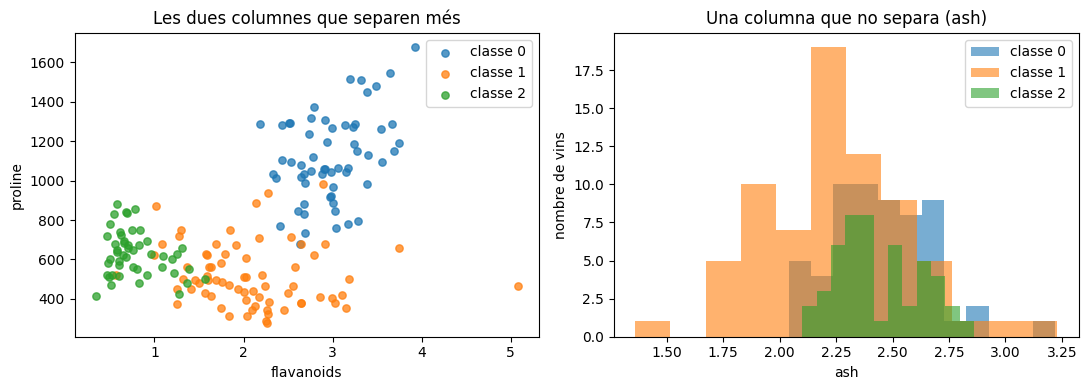

In [42]:
fig, (eix1, eix2) = plt.subplots(1, 2, figsize=(11, 4))

colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

for c in [0, 1, 2]:
    grup = vins[vins["classe"] == c]      # màscara booleana: les files d'aquesta classe
    eix1.scatter(grup["flavanoids"], grup["proline"],
                 color=colors[c], label=f"classe {c}", alpha=0.75, s=28)

eix1.set_xlabel("flavanoids")
eix1.set_ylabel("proline")
eix1.set_title("Les dues columnes que separen més")
eix1.legend()

for c in [0, 1, 2]:
    eix2.hist(vins[vins["classe"] == c]["ash"], bins=12,
              color=colors[c], label=f"classe {c}", alpha=0.6)

eix2.set_xlabel("ash")
eix2.set_ylabel("nombre de vins")
eix2.set_title("Una columna que no separa (ash)")
eix2.legend()

plt.tight_layout()
plt.show()

A l'esquerra, tres núvols bastant separats: es veu a ull que amb dues mesures ja es
distingeixen les varietats. A la dreta, els tres histogrames de `ash` estan encavalcats: si
només tinguessis aquesta columna, no sabries de quina varietat és un vi. Per això `ash`
sortia última al rànquing.

## Fi de l'Acte 1

Repassa el camí que has fet. No hi ha hagut cap moment de "ara toca aprendre `dir()`": cada
eina ha entrat perquè sense ella no podies continuar.

| | Pregunta | Què has fet servir a Wine | Què has trobat |
|---|---|---|---|
| **1** | Què és això? | `type()` sobre `dades`, `dades.data`, una columna | `Bunch`, `ndarray`, `DataFrame`, `Series` |
| **2** | Què porta dins? | `dir()` filtrat, `.keys()`, `.columns` | `data`, `target`, `feature_names`, `frame` |
| **3** | Quina mida i quins tipus? | `.shape`, `.dtypes`, `.info()`, `.head()`, `.describe()` | 178 x 14, tot numèric |
| **4** | Hi falta res? Repetits? | `.isna().sum()`, `.duplicated().sum()` | 0 i 0 |
| **5** | Com es reparteix el target? | `.value_counts()`, `.groupby().mean()` | 59/71/48; `flavanoids` separa, `ash` no |

Les cinc preguntes, en aquest ordre, són el mètode. Ara comprovem si de debò te l'endús.

---

# Acte 2 - I ara, amb un que no has vist mai

Unes dades noves. No et diré què hi trobaràs, no hi ha cap taula de mètodes i no hi ha cap
pista. Tens **les cinc preguntes**, i prou.

Són imatges de dígits escrits a mà, i la pregunta que les acompanya és: **es pot endevinar
quin número hi ha escrit?** Endavant.

In [43]:
from sklearn.datasets import load_digits

digits = load_digits()

# Pregunta 1
print(type(digits).__name__)

Bunch


Un `Bunch`, com Wine. Bona notícia: ja saps com s'obre.

**Pregunta 2: què porta dins?** Aquesta la fas tu. Tens dues maneres de respondre-la, i les
has fet servir totes dues fa deu minuts.

In [84]:
# EXERCICI - Pregunta 2: què porta dins?
# Respon-la de les dues maneres que coneixes:
#   a) dir() filtrat, per quedar-te només els noms sense guió baix davant
print(dir(digits))
#   b) .keys(), que és la via curta dels Bunch
print(list(digits.keys()))
# Compara la llista amb la de Wine: ['DESCR', 'data', 'feature_names', 'frame',
# 'target', 'target_names']. Què hi ha aquí que allà no hi era?

print("\n No hi ha images")

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']
['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR']

 No hi ha images


Si l'has feta, has vist que hi ha **un nom que a Wine no hi era**: `images`.

Ningú te n'ha parlat. No surt a cap taula d'aquest quadern ni te l'has après de memòria. **Ha
sortit perquè has fet la pregunta 2**, i això és exactament de què serveix el mètode: et
troba coses que no sabies que existien.

Anem a veure què és, amb la pregunta 3.

In [45]:
print("keys: ", list(digits.keys()))
print()
print("data:  ", digits.data.shape, digits.data.dtype)
print("images:", digits.images.shape, digits.images.dtype)
print("target:", digits.target.shape, " classes:", digits.target_names)

keys:  ['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR']

data:   (1797, 64) float64
images: (1797, 8, 8) float64
target: (1797,)  classes: [0 1 2 3 4 5 6 7 8 9]


`data` fa **1797 x 64** i `images` fa **1797 x 8 x 8**. El mateix primer número: 1797 mostres a
les dues. I 8 x 8 = 64.

Això fa pensar una cosa: que són **les mateixes dades guardades de dues maneres**. Una imatge
de 8 x 8 píxels aplanada en una fila de 64 números, i la mateixa imatge en forma de quadrat.

- `.data`, la fila de 64, és la forma que volen els models.
- `.images`, el quadrat, és la forma que vols per dibuixar-la.

**No t'ho creguis perquè ho digui jo. Comprova-ho.** `.reshape()` canvia la forma d'un array
sense tocar els números, i `np.array_equal(a, b)` diu si dos arrays són idèntics.

In [90]:
# EXERCICI - són el mateix?
# Agafa digits.images, que fa (1797, 8, 8), i canvia-li la forma a (1797, 64)
# amb .reshape(). Compara el resultat amb digits.data fent servir np.array_equal().

aplanades = digits.images.reshape(1797, 64)
print(np.array_equal(aplanades, digits.data))

True


T'ha de sortir `True`.

Cap dels dos atributs està explicat enlloc. Ho has esbrinat preguntant i comprovant, i aquesta
és tota la tècnica del quadern.

Ara que saps que `.images` és la versió quadrada, ja pots fer una cosa que amb `.data` no
podries: mirar-les.

In [47]:
print("la primera imatge, en forma de quadrat 8x8:")
print(digits.images[0].astype(int))
print()
print("i el seu target:", digits.target[0])

la primera imatge, en forma de quadrat 8x8:
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]

i el seu target: 0


Amb els números davant ja s'endevina un zero: els valors alts (13, 15, 16) dibuixen l'anell i
al mig hi ha el forat de zeros. Els valors van de 0 a 16, que és la intensitat del gris de cada
píxel. Dibuixem-los de debò:

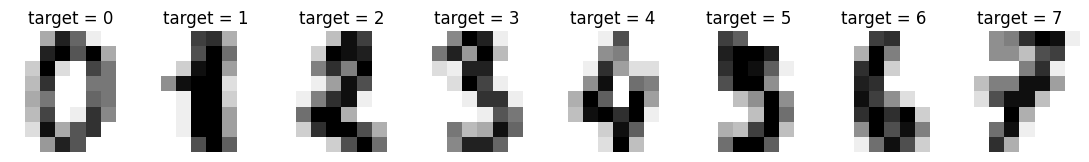

In [48]:
fig, eixos = plt.subplots(1, 8, figsize=(11, 1.8))
for i, eix in enumerate(eixos):
    eix.imshow(digits.images[i], cmap="gray_r")
    eix.set_title(f"target = {digits.target[i]}")
    eix.axis("off")
plt.tight_layout()
plt.show()

**Pregunta 4: hi falta res?** Amb `as_frame=True` tens les 1797 files x 64 píxels més el target
en una taula, i les dues línies de sempre.

In [49]:
taula_digits = load_digits(as_frame=True).frame

print("shape:", taula_digits.shape)
print("valors que falten:", taula_digits.isna().sum().sum())
print("files repetides:  ", taula_digits.duplicated().sum())
print()
print("tipus diferents que hi ha:", list(taula_digits.dtypes.unique()))

shape: (1797, 65)
valors que falten: 0
files repetides:   0

tipus diferents que hi ha: [dtype('float64'), dtype('int64')]


Net, com Wine, i pel mateix motiu: també és un dataset d'exemple.

**Pregunta 5: com es reparteix el que vull predir?** Aquesta també la fas tu. Compte amb una
cosa: `digits.target` és un array de NumPy, i `.value_counts()` és un mètode de les `Series`
de pandas, no dels arrays. Ho tens resolt de dues maneres, i les dues et serveixen.

In [130]:
# EXERCICI - Pregunta 5: com es reparteix el target?
# Quantes classes hi ha i quantes mostres de cada una?
#
# Dues vies, tria'n una:
#   a) pd.Series(digits.target).value_counts().sort_index()
#   b) la columna "target" de taula_digits, que ja és una Series
compte_digits = taula_digits["target"].value_counts()
compte_digits = compte_digits.sort_index()
print(compte_digits)
# Digues també quin és el número a batre: quin percentatge encertaria un model
# que sempre digués la classe més freqüent?

digits_percentatges = (compte_digits / len(taula_digits)).round(3).sort_index()
print(digits_percentatges)
print(f"Percentatge màxim: {digits_percentatges.max()}")

target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64
target
0    0.099
1    0.101
2    0.098
3    0.102
4    0.101
5    0.101
6    0.101
7    0.100
8    0.097
9    0.100
Name: count, dtype: float64
Percentatge màxim: 0.102


T'han de sortir **10 classes** (els dígits del 0 al 9) amb entre **174 i 183** mostres cada una:
el repartiment més equilibrat que et trobaràs mai. El número a batre és, doncs, d'un **10 %**
aproximadament, molt més baix que el 39.9 % de Wine. Amb deu classes és més difícil encertar
per casualitat.

## Fi de l'Acte 2

Les mateixes cinc preguntes, unes dades que no havies vist, i te n'has sortit sense que et
donessin cap llista de mètodes. I pel camí has trobat `.images`, que no surt a Wine i que
ningú t'havia dit que existís.

Això és el que hauria de passar cada vegada.

---

# Acte 3 - El model també és un objecte

Tornem als vins. Ja saps què hi ha a la taula i quines columnes separen les varietats; ara
entrenarem un model perquè ho faci ell.

I aquí el quadern fa el seu últim gir: **a un model se li fan exactament les mateixes cinc
preguntes que a les dades**. Perquè un model també és un objecte, i té una propietat que no
té cap dels altres: **canvia quan l'entrenes**. Té atributs que **no existeixen** fins que li
has donat dades.

Primer preparo les dades tal com les vol scikit-learn: les mesures en una banda (`X`) i la
resposta correcta a l'altra (`y`).

In [50]:
from sklearn.linear_model import LogisticRegression

X = vins.drop(columns=["classe"])    # DataFrame de 178 x 13
y = vins["classe"]                   # Series de 178

model = LogisticRegression(max_iter=20000, random_state=42)

# Pregunta 1
print(type(model).__name__)

LogisticRegression


Un `LogisticRegression`. Encara no ha vist cap vi: acabo de crear-lo.

**Pregunta 2: què porta dins?** Abans d'entrenar-lo. Un model té una versió pròpia d'aquesta
pregunta, `.get_params()`, que et diu amb quins ajustos l'has creat:

In [51]:
print("get_params(), els 6 primers:")
for clau, valor in list(model.get_params().items())[:6]:
    print(f"  {clau} = {valor}")

get_params(), els 6 primers:
  C = 1.0
  class_weight = None
  dual = False
  fit_intercept = True
  intercept_scaling = 1
  l1_ratio = None


Aquests són els ajustos que **tu** has triat (o que venen per defecte). No els ha après de
res: hi eren abans de veure cap dada.

I ara el `dir()` filtrat de sempre, amb un filtre de més: **els noms que acaben en guió baix**.
Aguanta la curiositat un moment i mira el resultat:

In [52]:
abans = [n for n in dir(model) if not n.startswith("_")]
apresos_abans = [n for n in abans if n.endswith("_")]

print("noms públics abans de fit():", len(abans))
print("dels quals acabats en '_': ", apresos_abans)

noms públics abans de fit(): 28
dels quals acabats en '_':  []


La llista és **buida**. Vint-i-set noms públics i cap que acabi en guió baix.

### Els dos errors que veuràs avui

Si li demanes una cosa que no ha après, això és el que passa. Els dos casos:

In [53]:
try:
    print(model.coef_)
except AttributeError as e:
    print(type(e).__name__, "->", e)

AttributeError -> 'LogisticRegression' object has no attribute 'coef_'


In [54]:
from sklearn.exceptions import NotFittedError

try:
    model.predict(X[:3])
except NotFittedError as e:
    print(type(e).__name__, "->")
    print(str(e)[:190])

NotFittedError ->
This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


Els dos diuen el mateix amb paraules diferents: **`AttributeError` si li demanes un atribut
après, `NotFittedError` si li demanes que treballi.** Tots dos volen dir "encara no has cridat
`.fit()`". Quan te'n surti un, no busquis el problema al nom del mètode: busca la línia del
`fit` que t'has deixat.

Ara l'entrenem, i tornem a fer la pregunta 2.

In [55]:
model.fit(X, y)

despres = [n for n in dir(model) if not n.startswith("_")]
apresos_despres = [n for n in despres if n.endswith("_")]

print("noms públics abans de fit():  ", len(abans))
print("noms públics després de fit():", len(despres))
print()
print("acabats en '_' que han APAREGUT:")
for n in apresos_despres:
    print("  ", n)

noms públics abans de fit():   28
noms públics després de fit(): 34

acabats en '_' que han APAREGUT:
   classes_
   coef_
   feature_names_in_
   intercept_
   n_features_in_
   n_iter_


De **27** noms públics a **33**: han aparegut **sis atributs nous**, i tots acaben en guió baix.
Abans no hi eren. El mateix objecte, la mateixa variable, i ara té coses a dins que no tenia.
Això és el que fa `.fit()`: no torna res útil, **modifica el model**.

### La convenció del guió baix al final

Ja saps què vol dir un guió baix **davant**: cosa interna de Python, no és per a tu. Doncs n'hi
ha una altra convenció, i és la que et desencallarà avui:

> **Un guió baix al FINAL del nom vol dir "això ho he après de les dades".**

`coef_`, `classes_`, `n_features_in_`, `feature_names_in_`, `intercept_`, `n_iter_`: tots
acaben en `_` i tots **només existeixen després de cridar `.fit()`**. No és decoració. És
l'avís que no els pots demanar abans.

Mirem què ha après, doncs.

In [56]:
print("classes_:         ", model.classes_)
print("n_features_in_:   ", model.n_features_in_)
print("n_iter_:          ", model.n_iter_, "voltes li ha calgut per aprendre")
print()
print("feature_names_in_: recorda com es deien les columnes")
print(model.feature_names_in_)

classes_:          [0 1 2]
n_features_in_:    13
n_iter_:           [3140] voltes li ha calgut per aprendre

feature_names_in_: recorda com es deien les columnes
['alcohol' 'malic_acid' 'ash' 'alcalinity_of_ash' 'magnesium'
 'total_phenols' 'flavanoids' 'nonflavanoid_phenols' 'proanthocyanins'
 'color_intensity' 'hue' 'od280/od315_of_diluted_wines' 'proline']


Val la pena aturar-se en dues d'aquestes. `n_iter_` diu **5476**: ha necessitat 5476 passades
sobre les dades per acabar. Això és moltíssim, i la culpa és de l'escala que has vist al
`.describe()` de l'Acte 1 (`alcohol` d'11 a 15, `proline` de 278 a 1680): quan les columnes
tenen mides tan diferents, el model triga molt a trobar el punt. Per això hi ha un
`max_iter=20000` allà dalt. A la sessió d'escalat ho arreglaràs, i el número baixarà de
cop.

`feature_names_in_` existeix perquè li has passat un `DataFrame` en lloc d'un array: el model
s'ha guardat els noms de les columnes. Si li haguessis passat `X.to_numpy()`, aquest atribut no
hi seria i n'apareixerien cinc en lloc de sis. **Els atributs apresos depenen del que li dones,
no només del model.**

I el que ha après de debò:

In [57]:
print("coef_.shape:", model.coef_.shape, "-> una fila per classe, una columna per mesura")
print()
print(pd.DataFrame(model.coef_.round(2),
                   columns=model.feature_names_in_,
                   index=[f"classe {c}" for c in model.classes_]
                  )[["flavanoids", "color_intensity", "proline", "ash"]])

coef_.shape: (3, 13) -> una fila per classe, una columna per mesura

          flavanoids  color_intensity  proline   ash
classe 0        0.83             0.22     0.01  0.72
classe 1        0.41            -1.05    -0.01 -0.86
classe 2       -1.24             0.83    -0.00  0.14


Llegeix la fila de la classe 2: **`flavanoids` té -1.23**, el pes més gran en valor absolut de
tota la taula. Vol dir "com menys flavanoids, més probable que sigui de la classe 2", i és
exactament el que havies trobat a mà a l'Acte 1, quan `flavanoids` va sortir primera al
rànquing de separació (2.20) i la classe 2 en tenia 0.78 contra 2.98.

I mira la columna `ash`, l'última del rànquing: pesos de 0.71, -0.85 i 0.14, petits i sense
un patró clar. **El model ha arribat sol a la mateixa conclusió que tu.**

Ara que està entrenat, ja pot treballar:

In [58]:
print("score sobre les mateixes dades:", round(model.score(X, y), 4))
print()
print("predict dels 8 primers vins:", model.predict(X[:8]))
print("el que eren de veritat:     ", y[:8].to_numpy())

score sobre les mateixes dades: 0.9944

predict dels 8 primers vins: [0 0 0 0 0 0 0 0]
el que eren de veritat:      [0 0 0 0 0 0 0 0]


`0.9944`: encerta 177 dels 178 vins. Molt per damunt del 39.9 % que hauria tret dient sempre
"classe 1".

(Avaluar sobre les mateixes dades amb què has entrenat està malament fet, i és el tema sencer
de la sessió de validació. Aquí només volíem que `.score()` tornés un número.)

### Un model diferent aprèn coses diferents

Cada família de models aprèn una cosa seva, i per tant té atributs acabats en `_` diferents. Si
agafes un model que no has fet servir mai, **no te l'has de buscar: li fas la pregunta 2**.

In [59]:
from sklearn.tree import DecisionTreeClassifier

arbre = DecisionTreeClassifier(random_state=42).fit(X, y)

print("atributs apresos de l'arbre:")
print([n for n in dir(arbre) if not n.startswith("_") and n.endswith("_")])
print()
print("hi ha 'coef_' a dir(arbre)?    ", "coef_" in dir(arbre))
print("hi ha 'coef_' al model lineal?", "coef_" in dir(model))

atributs apresos de l'arbre:
['classes_', 'feature_importances_', 'feature_names_in_', 'max_features_', 'n_classes_', 'n_features_in_', 'n_outputs_', 'tree_']

hi ha 'coef_' a dir(arbre)?     False
hi ha 'coef_' al model lineal? True


Vuit atributs apresos, i **cap es diu `coef_`**. L'arbre no té coeficients, perquè un arbre no
és un model lineal: no multiplica les columnes per pesos, les va partint per llindars. El que
té, i la regressió logística no, és `feature_importances_`.

In [60]:
importancies = pd.Series(arbre.feature_importances_, index=X.columns)

print(importancies.sort_values(ascending=False).round(3))

proline                         0.382
od280/od315_of_diluted_wines    0.312
flavanoids                      0.141
hue                             0.084
alcohol                         0.047
magnesium                       0.033
alcalinity_of_ash               0.000
malic_acid                      0.000
ash                             0.000
proanthocyanins                 0.000
nonflavanoid_phenols            0.000
total_phenols                   0.000
color_intensity                 0.000
dtype: float64


L'arbre diu que amb **tres** columnes ja en té prou: `proline` (**0.382**),
`od280/od315_of_diluted_wines` (**0.312**) i `flavanoids` (**0.141**), que sumen el 0.835. Les
altres set les deixa a **0.000**: no les ha fet servir ni una vegada.

Compara-ho amb el teu rànquing de l'Acte 1: `flavanoids` 2.20,
`od280/od315_of_diluted_wines` 2.08, `proline` 1.89. **Les tres mateixes columnes, en un ordre
lleugerament diferent.** Tu ho vas calcular amb una divisió; l'arbre ho ha après de les dades.

## La conclusió del quadern

El mètode de les cinc preguntes serveix per a les dades i serveix per als models. Són el
mateix tipus de cosa: objectes als quals es pot preguntar.

> **Un model entrenat no és una caixa negra. És un objecte, i se li pot preguntar què ha
> après.**

`type()` per saber què és, `dir()` filtrat per saber què porta, el guió baix final per saber
què ha tret de les dades, i els parèntesis per saber si demanes una dada o una feina. Res
d'això te l'has de recordar de memòria: és el que acabes de fer tres vegades.

---

# La xuleta

Aquí baixa tot el material de consulta. Ara ja té sentit, perquè cada mètode que hi surt l'has
fet servir en algun moment de les últimes dues hores. **Torna-hi quan estiguis encallat.**

## Les quatre eines per interrogar qualsevol objecte

| Quan | Eina |
|---|---|
| Estic escrivint i vull veure què hi ha | **TAB** |
| Vull la llista completa, per llegir-la amb calma | `dir(objecte)` filtrat |
| He trobat un mètode i no sé què li he de passar | `objecte.metode?` |
| No sé ni de quin tipus és el que tinc | `type(objecte)` |

### `help()` i el signe d'interrogació

`dir()` et diu **que una cosa existeix**. No et diu què fa ni quins arguments vol. Per això hi
ha `help()`:

In [61]:
mostra = [3, 1, 4, 1, 5]

help(mostra.count)

Help on built-in function count:

count(value, /) method of builtins.list instance
    Return number of occurrences of value.



Amb això ja el pots fer servir: t'ha dit com es crida (`count(value, /)`) i què fa.

**La versió curta, i la que faràs servir de debò:** a Colab i a Jupyter pots posar un `?`
darrere del nom.

```python
mostra.count?
```

Escriu-ho en una cel·la nova i executa-la: la documentació s'obre en un **panell a baix de la
pantalla**, sense embrutar la sortida. Amb dos interrogants (`mostra.count??`) veus fins i tot
el codi font, quan està escrit en Python.

Amb pandas i scikit-learn els textos d'ajuda són llarguíssims (el de `DataFrame.groupby` fa
desenes de línies) i al panell es llegeixen molt millor que enmig del quadern.

> Compte: `mostra.count?` **només** funciona dins d'un quadern. En un fitxer `.py` és un error
> de sintaxi; allà has de fer servir `help(mostra.count)`.

### La tecla TAB

Aquesta és la més important de les quatre i és l'única que no es pot ensenyar amb una cel·la
executada: l'has de fer tu.

**Escriu el nom d'un objecte, un punt, i prem TAB.** Surt una llista amb tot el que pots posar
després del punt, i mentre escrius lletres es va escurçant.

Prova-ho ara. Crea una cel·la nova, escriu això **sense executar-ho**:

```python
vins.
```

i amb el cursor just darrere del punt, prem **TAB**. Apareixeran `abs`, `add`, `agg`, `align`,
`all`... Ara escriu `des` (`vins.des`) i torna a prémer TAB: només queda `describe`.

Això és **la manera normal de treballar**. No és una drecera per a principiants: és com ho fa
tothom, tot el dia, i és la que faràs servir el 90 % de les vegades. Ningú es recorda de
memòria els noms dels mètodes de pandas, i ningú els busca a Google un per un. Es prem TAB i es
tria de la llista.

## `que_te()`: la funció que faràs servir tot el curs

Ajuntem-ho tot en una sola funció. Li passes un objecte qualsevol i t'imprimeix de quin tipus
és, quins atributs públics té i quins mètodes públics té, **separats**, que és justament el que
`dir()` no fa.

Copia-la als teus quaderns. Com distingeix els atributs dels mètodes? Amb `callable()`,
exactament com has vist a l'Acte 1.

In [62]:
def que_te(objecte, filtre=""):
    """Imprimeix el tipus, els atributs públics i els mètodes públics d'un objecte.

    Amb `filtre`, només mostra els noms que contenen aquell text:
    que_te(df, "na") per trobar isna, dropna, fillna...
    """
    atributs = []
    metodes = []
    for nom in dir(objecte):
        if nom.startswith("_") or filtre not in nom:
            continue
        try:
            valor = getattr(objecte, nom)
        except Exception:
            continue          # n'hi ha que peten si encara no existeixen: les saltem
        if callable(valor):
            metodes.append(nom)
        else:
            atributs.append(nom)

    print("TIPUS:", type(objecte).__name__)
    print()
    print(f"ATRIBUTS ({len(atributs)}) - sense parèntesis:")
    print("  " + (", ".join(atributs) if atributs else "(cap)"))
    print()
    print(f"MÈTODES ({len(metodes)}) - amb parèntesis:")
    print("  " + (", ".join(metodes) if metodes else "(cap)"))


que_te(vins)

TIPUS: DataFrame

ATRIBUTS (28) - sense parèntesis:
  T, alcalinity_of_ash, alcohol, ash, at, attrs, axes, classe, color_intensity, columns, dtypes, empty, flags, flavanoids, hue, iat, index, magnesium, malic_acid, ndim, nonflavanoid_phenols, proanthocyanins, proline, shape, size, style, total_phenols, values

MÈTODES (193) - amb parèntesis:
  abs, add, add_prefix, add_suffix, agg, aggregate, align, all, any, apply, applymap, asfreq, asof, assign, astype, at_time, backfill, between_time, bfill, bool, boxplot, clip, combine, combine_first, compare, convert_dtypes, copy, corr, corrwith, count, cov, cummax, cummin, cumprod, cumsum, describe, diff, div, divide, dot, drop, drop_duplicates, droplevel, dropna, duplicated, eq, equals, eval, ewm, expanding, explode, ffill, fillna, filter, first, first_valid_index, floordiv, from_dict, from_records, ge, get, groupby, gt, head, hist, idxmax, idxmin, iloc, infer_objects, info, insert, interpolate, isetitem, isin, isna, isnull, items, iterrows, ite

28 atributs i 193 mètodes: un DataFrame té molta cosa. Dues observacions sobre aquesta sortida,
perquè si no et despistaran:

- Entre els atributs hi surten `alcohol`, `proline`, `classe` i companyia, que són **els noms de
  les columnes**. pandas les exposa també com a atributs, i per això `vins.alcohol` funciona
  igual que `vins["alcohol"]`. Amb els claudàtors sempre funciona; amb el punt, no (prova-ho
  amb `od280/od315_of_diluted_wines`).
- `loc` i `iloc` han anat a la llista de mètodes, perquè `callable()` diu que sí. Són
  l'excepció de tot plegat: es fan servir amb **claudàtors**, `vins.loc[8, "alcohol"]`.

Com que la llista és tan llarga, `que_te()` accepta un filtre: quan busques una cosa concreta i
no recordes com es diu, filtra per un tros del nom. Per exemple, saps que hi ha alguna cosa per
als valors que falten i que en anglès es diu "NA":

In [63]:
que_te(vins, "na")

TIPUS: DataFrame

ATRIBUTS (0) - sense parèntesis:
  (cap)

MÈTODES (6) - amb parèntesis:
  dropna, fillna, isna, notna, rename, rename_axis


`isna`, `dropna`, `fillna`, `notna`: els que buscaves. També hi surten `rename` i `rename_axis`,
perquè el filtre és una cerca de text ximple i "rename" conté "na". No hi passa res: sis noms es
llegeixen en un segon, 193 no.

## Els cinc objectes del curs

### `Bunch` - el que et torna `load_wine()`, `load_digits()`, `load_iris()`

No són les dades: és la capsa que les porta a dins, amb les etiquetes, els noms de les columnes
i la descripció.

| | Nom | Què és |
|---|---|---|
| atribut | `.data` | les dades: array 2D, files = mostres, columnes = característiques |
| atribut | `.target` | la resposta correcta de cada fila: array 1D de números |
| atribut | `.feature_names` | els noms de les columnes de `.data` |
| atribut | `.target_names` | a què correspon cada número de `.target` |
| atribut | `.DESCR` | la descripció del dataset, en text |
| atribut | `.frame` | tot el dataset en un DataFrame, **només si has demanat `as_frame=True`** |
| atribut | `.images` | **només a `load_digits`**: les mateixes dades en forma d'imatge 8x8 |
| mètode | `.keys()` | què porta a dins (perquè un `Bunch` també és un diccionari) |

`.DESCR` és un text llarg amb la fitxa del dataset: d'on surt, què vol dir cada columna, quantes
mostres hi ha. No l'imprimeixis sencer, que fa mig metre; talla'l.

In [64]:
print(type(dades.DESCR).__name__, "de", len(dades.DESCR), "caràcters")
print()
print(dades.DESCR[:330])

str de 3355 caràcters

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - F


### `ndarray` - l'array de NumPy

És el que hi ha dins de `.data`. Files = mostres, columnes = característiques.

| | Nom | Què és |
|---|---|---|
| atribut | `.shape` | la forma: `(files, columnes)` |
| atribut | `.dtype` | el tipus de dada que guarda: `float64`, `int64`... |
| atribut | `.ndim` | quantes dimensions té: 1 = fila, 2 = taula |
| atribut | `.size` | quants números hi ha en total |
| atribut | `.T` | el mateix array transposat (files per columnes) |
| mètode | `.mean()` `.std()` | mitjana, desviació típica |
| mètode | `.min()` `.max()` `.sum()` | mínim, màxim, suma |
| mètode | `.argmin()` `.argmax()` | **la posició** del mínim i del màxim, no el valor |
| mètode | `.reshape()` | canvia la forma sense canviar els números (com a l'Acte 2) |
| mètode | `.copy()` | una còpia independent |
| mètode | `.astype()` | el mateix array amb un altre tipus de dada |
| mètode | `.round()` | arrodonit a tants decimals |

#### `axis`: el que costa més de tots

Els mètodes de resum (`.mean()`, `.sum()`, `.max()`...) es comporten de tres maneres segons què
li posis a `axis`:

- **`numeros.mean()`**, sense res: un **sol número**, la mitjana dels 2314 valors alhora.
  Gairebé mai és el que vols.
- **`numeros.mean(axis=0)`**, "aixafa les files": **un número per columna**. La mitjana de cada
  mesura. **És el que voldràs el 90 % de les vegades.**
- **`numeros.mean(axis=1)`**, "aixafa les columnes": **un número per fila**. La mitjana de cada
  vi, que aquí no vol dir gran cosa (barreja graus d'alcohol amb mil·ligrams de magnesi).

El truc per recordar-ho: `axis` diu **quin eix desapareix**. `axis=0` és l'eix de les files, i el
resultat ja no té files: en queda un valor per columna.

In [65]:
print("numeros.shape        ->", numeros.shape)
print("numeros.mean()       ->", round(numeros.mean(), 4), " (un sol número)")
print()
with np.printoptions(suppress=True):     # sense notació científica, que es llegeix millor
    print("mean(axis=0), shape", numeros.mean(axis=0).shape, "-> un valor per COLUMNA:")
    print(" ", numeros.mean(axis=0).round(2))
    print("mean(axis=1), shape", numeros.mean(axis=1).shape, "-> un valor per FILA (els 5 primers):")
    print(" ", numeros.mean(axis=1)[:5].round(2))
print()
# argmax NO dona el valor: dona la POSICIÓ
columna_proline = numeros[:, 12]
print("el proline més alt és     ", columna_proline.max())
print("i és el del vi número     ", columna_proline.argmax())
print("comprovació:              ", columna_proline[columna_proline.argmax()])

numeros.shape        -> (178, 13)
numeros.mean()       -> 69.1337  (un sol número)

mean(axis=0), shape (13,) -> un valor per COLUMNA:
  [ 13.     2.34   2.37  19.49  99.74   2.3    2.03   0.36   1.59   5.06
   0.96   2.61 746.89]
mean(axis=1), shape (178,) -> un valor per FILA (els 5 primers):
  [ 95.77  91.85 103.22 126.96  69.9 ]

el proline més alt és      1680.0
i és el del vi número      18
comprovació:               1680.0


### `DataFrame` - la taula de pandas

Un array amb noms a les columnes i moltíssims mètodes d'anàlisi. És el que faràs servir per
**mirar** les dades; l'array és el que faràs servir per **entrenar** els models.

| | Nom | Què és |
|---|---|---|
| atribut | `.shape` | `(files, columnes)` |
| atribut | `.columns` | els noms de les columnes |
| atribut | `.index` | les etiquetes de les files |
| atribut | `.dtypes` | el tipus de cada columna, una per una |
| atribut | `.values` | les dades com a array de NumPy, sense els noms |
| atribut | `.loc` | selecció **per etiqueta**: `df.loc[3, "nota"]` |
| atribut | `.iloc` | selecció **per posició**: `df.iloc[0, 1]` |
| mètode | `.head()` `.tail()` | les primeres / les últimes files |
| mètode | `.info()` | resum: columnes, tipus, quants valors no nuls, memòria |
| mètode | `.describe()` | estadístiques de cada columna numèrica |
| mètode | `.isna()` | on falten valors (True/False a cada casella) |
| mètode | `.dropna()` `.fillna()` | treure les files amb buits / omplir-los |
| mètode | `.groupby()` | agrupar per una columna per calcular per grup |
| mètode | `.sort_values()` | ordenar per una columna |
| mètode | `.value_counts()` | comptar quantes vegades surt cada valor |
| mètode | `.drop()` | treure columnes o files |
| mètode | `.copy()` | una còpia independent |
| mètode | `.duplicated()` `.drop_duplicates()` | trobar / treure files repetides |

### `Series` - una columna

Una columna d'un DataFrame **no és un DataFrame**: és una `Series`, amb els seus propis mètodes.
Té els atributs que ja coneixes (`.shape`, `.dtype`, `.values`, `.index`, `.name`) i, a més:

| | Nom | Què és |
|---|---|---|
| mètode | `.value_counts()` | quantes vegades surt cada valor, de més a menys |
| mètode | `.unique()` | quins valors diferents hi ha |
| mètode | `.nunique()` | quants valors diferents hi ha |
| mètode | `.map()` | aplica una funció o un diccionari a cada valor |
| mètode | `.astype()` | canvia el tipus de dada |
| mètode | `.mean()` `.std()` `.min()` `.max()` `.sum()` | com a NumPy |
| mètode | `.idxmax()` `.idxmin()` | l'**índex** de la fila del màxim i del mínim |

`.map()` no ha sortit al quadern i val la pena veure'l: serveix per traduir valors, per exemple
els números del target als noms de les varietats.

In [66]:
noms = dades.target_names
print("target_names:", noms)

etiquetes = vins["classe"].map({0: noms[0], 1: noms[1], 2: noms[2]})
print()
print("type:", type(etiquetes).__name__)
print(etiquetes.head(3))
print()
print(etiquetes.value_counts())

target_names: ['class_0' 'class_1' 'class_2']

type: Series
0    class_0
1    class_0
2    class_0
Name: classe, dtype: object

classe
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


### Un model de scikit-learn

| | Nom | Què és |
|---|---|---|
| mètode | `.fit(X, y)` | **entrena**: aprèn dels exemples |
| mètode | `.predict(X)` | prediu la classe de mostres noves |
| mètode | `.score(X, y)` | quina proporció encerta |
| mètode | `.get_params()` | amb quins ajustos l'has creat |
| atribut | `.coef_` | el que ha après: el pes de cada característica (models lineals) |
| atribut | `.classes_` | quines classes ha vist |
| atribut | `.n_features_in_` | quantes columnes esperava |
| atribut | `.feature_names_in_` | com es deien, si li has passat un DataFrame |
| atribut | `.n_iter_` | quantes voltes li ha calgut per aprendre |
| atribut | `.feature_importances_` | (als models d'arbre) quant compta cada columna |

## Les tres taules que val la pena recordar

**Els dos guions baixos:**

| On | Què vol dir | Exemple |
|---|---|---|
| al **davant** | cosa interna de Python, no és per a tu | `__len__`, `__init__` |
| al **final** | ho ha après de les dades, **només existeix després de `.fit()`** | `coef_`, `classes_` |

**Atribut o mètode:**

- Atribut = una dada guardada, **sense** parèntesis: `df.shape`, `X.dtype`, `model.coef_`.
- Mètode = una acció, **amb** parèntesis: `df.head()`, `X.mean()`, `model.fit(X, y)`.
- `callable(objecte.nom)` t'ho diu, si tens dubtes.
- `.loc` i `.iloc` són l'excepció: atributs, però amb claudàtors.

**Els tres errors que has vist avui:**

| Error | Vol dir |
|---|---|
| `TypeError: 'tuple' object is not callable` | has posat parèntesis a un atribut |
| a la sortida surt `method` o `bound method` | t'has deixat els parèntesis d'un mètode |
| `AttributeError: coef_` o `NotFittedError` | no has cridat `.fit()` |

## I, sobretot, les cinc preguntes

| | Pregunta | Amb què es respon | Per què |
|---|---|---|---|
| **1** | Què és això? | `type()` | el que pots fer-hi depèn del que sigui |
| **2** | Què porta dins? | `dir()` filtrat, `.keys()`, `.columns` | perquè no t'ho has de saber de memòria |
| **3** | Quina mida i quins tipus? | `.shape`, `.dtypes`, `.info()`, `.head()` | per saber amb què tractes abans de calcular |
| **4** | Hi falta res? Repetits? | `.isna().sum()`, `.duplicated().sum()` | perquè un buit et falseja la mitjana sense avisar |
| **5** | Com es reparteix el target? | `.value_counts()`, `.groupby()` | per tenir el número a batre |

I la pregunta 1 es repeteix amb cada cosa que treguis de dins d'una altra. Aquest és tot el
mètode.

Quan un exercici et posi al davant un objecte que no coneixes, ja no estàs encallat: li
preguntes.

---

# Exercicis - ara tu

Quatre preguntes sobre les dades dels vins. **A cada enunciat et dic quins mètodes has de fer
servir**: el nom de la funció no és el que has de descobrir. El que has de descobrir és **el
que surt de les dades**.

Si en algun moment no recordes com es diu alguna cosa, ja saps què fer: `que_te(vins)`,
`que_te(vins, "sort")`, TAB, o `vins.sort_values?`.

### Exercici 1 - Els cinc vins més alcohòlics

Amb **`.sort_values()`** i **`.head()`**: quins són els cinc vins amb més alcohol, i de quina
classe són?

`.sort_values("columna")` ordena de menys a més. Per ordenar de més a menys li has de passar
`ascending=False`. Imprimeix només les columnes `alcohol` i `classe`, que si no surten catorze.

In [ ]:
# Exercici 1

# ordenats = vins.sort_values("alcohol", ascending=False)
# imprimeix les 5 primeres files, només les columnes alcohol i classe:
#   ordenats[["alcohol", "classe"]].head(5)

**Com saps que ho has fet bé:** el primer ha de tenir `14.83` graus (és el que hem trobat amb
`.idxmax()` a l'Acte 1). I mira la columna `classe` dels cinc: no és casualitat, amb
`.groupby().mean()` hem vist quina varietat era la més alcohòlica.

### Exercici 2 - Quina varietat és més uniforme

Amb **`.groupby()`** i **`.std()`**: per a la columna `proline`, quina de les tres classes té
els vins més semblants entre ells?

La desviació típica mesura com de dispersos són els valors: com més petita, més semblants entre
ells. Agrupa per `classe`, agafa la columna `proline` i demana-li `.std()`. Compara-ho després
amb `.mean()` del mateix grup: la classe amb la mitjana més alta, és també la més dispersa?

In [ ]:
# Exercici 2

# desviacions = vins.groupby("classe")["proline"].std()
# mitjanes_proline = vins.groupby("classe")["proline"].mean()
# imprimeix les dues i digues quina classe és la més uniforme

**Com saps que ho has fet bé:** t'han de sortir tres números, un per classe, i la classe amb la
desviació més petita és la més uniforme. Pista sobre el resultat: la classe que té la mitjana de
`proline` més alta és també la que la té més dispersa, que és un patró habitualíssim en mesures
físiques.

### Exercici 3 - Els vins per damunt de la mitjana

Amb una **màscara booleana** i **`.value_counts()`**: quants vins tenen més alcohol que la
mitjana del dataset, i com es reparteixen per classe?

Calcula primer la mitjana amb `vins["alcohol"].mean()`. Després construeix la màscara
(`vins["alcohol"] > mitjana`), que és una Series de True i False. Aplica-la al DataFrame
(`vins[mascara]`) i demana `.value_counts()` a la columna `classe` del resultat.

In [ ]:
# Exercici 3

# mitjana_alcohol = vins["alcohol"].mean()
# mascara = vins["alcohol"] > mitjana_alcohol
# imprimeix quants en són: mascara.sum()
# imprimeix el repartiment: vins[mascara]["classe"].value_counts().sort_index()

**Com saps que ho has fet bé:** `mascara.sum()` t'ha de donar un número entre 0 i 178, i força a
prop de la meitat. Al repartiment per classe, la classe 1 hi ha de ser molt poc representada: és
la de menys alcohol (12.28, per sota de la mitjana general, que és 13.00).

### Exercici 4 - La fitxa del vi més extrem

Amb **`.idxmax()`** i **`.loc`**: troba el vi amb el `color_intensity` més alt i imprimeix la
seva fila sencera. De quina classe és?

`.idxmax()` sobre la columna et dona l'índex de la fila; `vins.loc[aquell_index]` et dona la
fila. Compara després els seus valors amb les mitjanes de la seva classe
(`mitjanes.loc[la_seva_classe]`): en què es desvia més del que és normal a la seva varietat?

In [ ]:
# Exercici 4

# posicio = vins["color_intensity"].idxmax()
# fila = vins.loc[posicio]
# imprimeix posicio i fila
# mira de quina classe és: fila["classe"]
# compara-ho amb: mitjanes.loc[fila["classe"]]

**Com saps que ho has fet bé:** `fila` és una **Series** (una fila d'un DataFrame també és una
Series, amb els noms de columna com a índex), no un DataFrame. Comprova-ho amb `type(fila)`. I la
classe que et surti hauria de ser la que tenia el `color_intensity` mitjà més alt (7.40).